# Biodiversity response variables — exploration

Built by `scripts/07_compute_taxonomic_beta_responses.R`. Phase 1 only — see
`README.md` ("Variables respuesta") for scope: taxonomic diversity (Hill numbers),
LCBD (Legendre & De Caceres 2013) and composition (PCoA). Phylogenetic diversity,
functional diversity and dark diversity are a separate, not-yet-implemented phase 2.

Unit of analysis: **one vegetation plot** (`PlotObservationID`), same 1,082-plot subset
as `notebooks/01_explore_phenology_db.ipynb`. Two abundance tiers, per the design
agreed in the README:

- **presence/absence** (`*_pa` columns) — all 1,082 plots, Jaccard dissimilarity.
- **cover-weighted** (`*_cover` columns) — only the `cover` stratum (~546 plots,
  `Cover` + `Cover_st`), Hellinger/Bray-Curtis. `NA` outside that stratum by
  design — no plot is ever dropped or imputed.

Composition axes are **PCoA**, not NMDS: with median richness = 5 species/plot, NMDS
(`vegan::metaMDS`) produced unstable solutions — plots with almost no shared species
got flung to absurd values on one axis by the iterative optimizer, a known NMDS
pathology at this level of sparsity. PCoA (`ape::pcoa`, Cailliez correction for the
negative eigenvalues that Jaccard/Bray produce) is a deterministic eigendecomposition
without that failure mode.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DERIVED = Path('../data/derived')

# Informal palette for exploration (not the paper's Okabe-Ito set in biodiv.figures --
# this notebook is not a source of figures for the manuscript).
BLUE, ORANGE, GREEN, RED, PURPLE = '#4C78A8', '#F58518', '#54A24B', '#E45756', '#B279A2'

resp = pd.read_parquet(DERIVED / 'biodiversity_responses.parquet')
plots = pd.read_parquet(DERIVED / 'plots_subset.parquet')
df = resp.merge(plots, on='PlotObservationID', how='left')

print('responses:', resp.shape)
print('merged   :', df.shape)
df.head()

responses: (1082, 12)
merged   : (1082, 30)


,PlotObservationID,hill_q0,hill_q1,hill_q2,lcbd_pa,p_lcbd_pa,pcoa1_pa,pcoa2_pa,lcbd_cover,p_lcbd_cover,...,lat,richness,n_records,stratum,Abundance_parameter,pixel_id,cell,win_start,win_end,win_years
0,32477,6.0,1.366220,1.145429,0.001058,0.001,0.137374,-0.144168,NaN,NaN,...,-30.65956,6,6,basal,Basal_area,8120_220169,49_1321,2001,2003,3
1,32479,4.0,1.428481,1.231409,0.001057,0.001,0.133980,-0.148337,NaN,NaN,...,-30.67519,4,4,basal,Basal_area,8121_220111,49_1321,2001,2003,3
2,32532,2.0,1.842709,1.725184,0.001070,0.001,0.156468,-0.104593,NaN,NaN,...,-37.80289,2,2,basal,Basal_area,4856_193614,29_1162,2010,2012,3
3,32644,25.0,9.656716,7.633149,0.001062,0.001,0.143443,-0.127482,0.002513,0.001,...,-37.82255,25,25,cover,Cover,4939_193545,30_1161,2004,2006,3
4,32645,31.0,8.621083,4.548669,0.001066,0.001,0.151469,-0.114513,0.002524,0.001,...,-37.82302,31,31,cover,Cover,4937_193543,30_1161,2004,2006,3


## 1. Taxonomic diversity (Hill numbers)

`hill_q0`, `hill_q1`, `hill_q2` are the same "effective number of species" family at
increasing sensitivity to abundance: q=0 is plain richness (should match the
`richness` column from `plots_subset.parquet` exactly), q=1 is the exponentiated
Shannon index, q=2 is the inverse Simpson index. The gap between q0 and q1 is an
evenness signal — a plot dominated by one species has q1 much lower than q0 even at
identical richness.

hill_q0 == richness: 100.0000% of plots (0 mismatches)


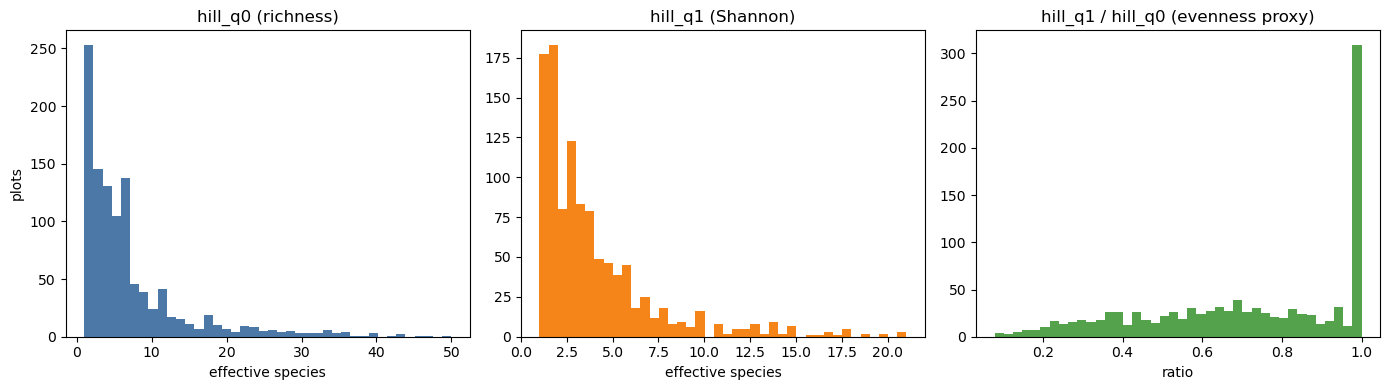

In [2]:
mismatch = (df['hill_q0'] - df['richness']).abs() > 1e-6
print(f"hill_q0 == richness: {(~mismatch).mean():.4%} of plots "
      f"({mismatch.sum()} mismatches)")

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].hist(df['hill_q0'], bins=40, color=BLUE)
ax[0].set(title='hill_q0 (richness)', xlabel='effective species', ylabel='plots')
ax[1].hist(df['hill_q1'], bins=40, color=ORANGE)
ax[1].set(title='hill_q1 (Shannon)', xlabel='effective species')
ax[2].hist(df['hill_q1'] / df['hill_q0'], bins=40, color=GREEN)
ax[2].set(title='hill_q1 / hill_q0 (evenness proxy)', xlabel='ratio')
fig.tight_layout()

## 2. Beta diversity (LCBD)

Local Contribution to Beta Diversity: how much each plot contributes to the total
compositional variance of the dataset — high LCBD marks compositionally unusual
plots, not species-rich ones (a species-poor but atypical plot can outscore a
species-rich, typical one). `p_lcbd_*` is the permutation-test p-value (999 perms) for
each plot's LCBD; `lcbd_pa`/`lcbd_cover` are computed on separate abundance tiers, so
they answer slightly different questions (compositional uniqueness by presence/absence
vs by relative cover) and need not agree for a given plot.

p_lcbd_pa: 274 / 1082 plots significant (p<0.05)
p_lcbd_cover: 81 / 546 plots significant (p<0.05)

corr(lcbd_pa, lcbd_cover) on the 546 plots with both = 0.902


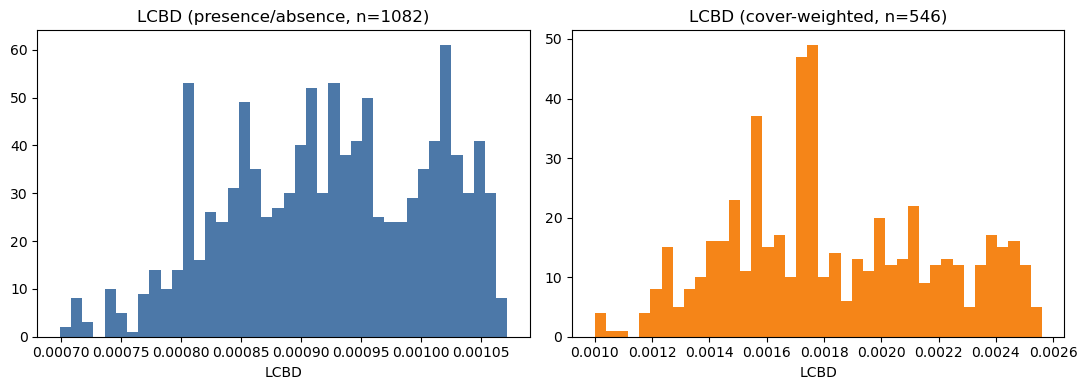

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(df['lcbd_pa'], bins=40, color=BLUE)
ax[0].set(title='LCBD (presence/absence, n=1082)', xlabel='LCBD')
ax[1].hist(df['lcbd_cover'].dropna(), bins=40, color=ORANGE)
ax[1].set(title='LCBD (cover-weighted, n=%d)' % df['lcbd_cover'].notna().sum(),
          xlabel='LCBD')
fig.tight_layout()

for col in ['p_lcbd_pa', 'p_lcbd_cover']:
    sig = df[col] < 0.05
    print(f"{col}: {sig.sum()} / {df[col].notna().sum()} plots significant (p<0.05)")

both = df.dropna(subset=['lcbd_pa', 'lcbd_cover'])
print(f"\ncorr(lcbd_pa, lcbd_cover) on the {len(both)} plots with both = "
      f"{both['lcbd_pa'].corr(both['lcbd_cover']):.3f}")

## 3. Composition (PCoA)

Two axes per tier. `%` variance explained is printed by the R script (check its log)
— PCoA is not rank-2 by construction the way a 2D NMDS solution is, so a low value
here is informative in a way NMDS stress is not: it says the two axes genuinely do not
capture much of the compositional variance, rather than saying the optimizer struggled.

Plots with almost no shared species can still dominate an eigenvector even without
NMDS's iterative instability. The same MAD-based rule the R script uses to flag
outliers is recomputed here to mark them on the scatter rather than silently plot
through them.

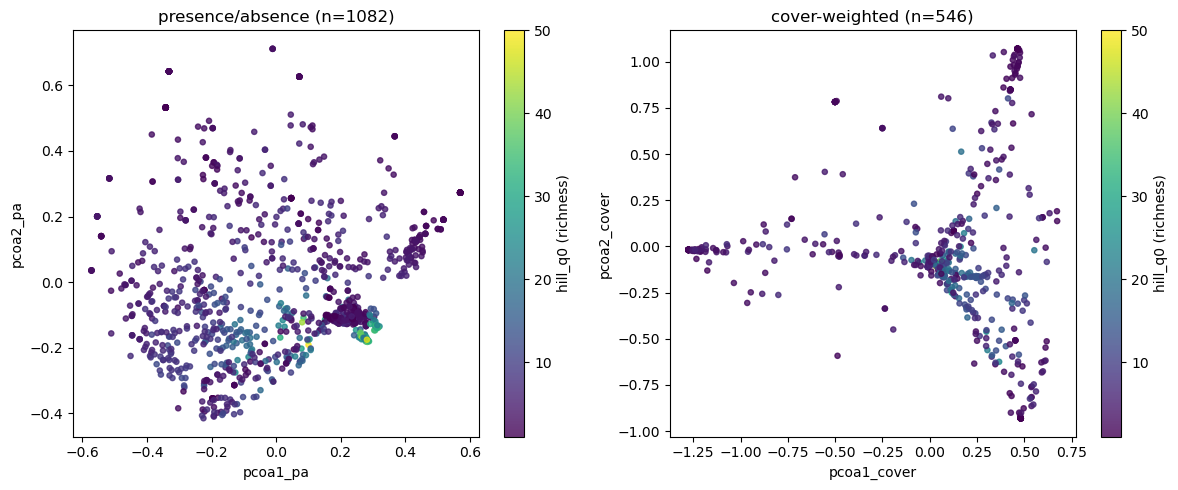

In [4]:
def mad_outliers(x, thresh=10.0):
    x = x.dropna()
    mad = (x - x.median()).abs().median() * 1.4826
    z = (x - x.median()).abs() / mad
    return x.index[z > thresh]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (x_col, y_col, title) in zip(axes, [
    ('pcoa1_pa', 'pcoa2_pa', 'presence/absence (n=1082)'),
    ('pcoa1_cover', 'pcoa2_cover', 'cover-weighted (n=%d)' % df['pcoa1_cover'].notna().sum()),
]):
    sub = df.dropna(subset=[x_col, y_col])
    outliers = mad_outliers(sub[x_col]).union(mad_outliers(sub[y_col]))
    ok = sub.index.difference(outliers)
    sc = ax.scatter(sub.loc[ok, x_col], sub.loc[ok, y_col],
                     c=sub.loc[ok, 'hill_q0'], cmap='viridis', s=14, alpha=0.8)
    if len(outliers):
        ax.scatter(sub.loc[outliers, x_col], sub.loc[outliers, y_col],
                    marker='x', color=RED, s=80, label='flagged outlier')
        for pid in outliers:
            print(f"[{title}] outlier: {df.loc[pid, 'PlotObservationID']}")
    ax.set(title=title, xlabel=x_col, ylabel=y_col)
    if len(outliers):
        ax.legend()
    fig.colorbar(sc, ax=ax, label='hill_q0 (richness)')
fig.tight_layout()

## 4. Two-tier coverage

`*_cover` columns exist only for the `cover` abundance stratum — everything else is
`NA` by design (never imputed, never dropped). Sanity-check the NA pattern against
`plots_subset.parquet`'s own `stratum` column before trusting the merge above.

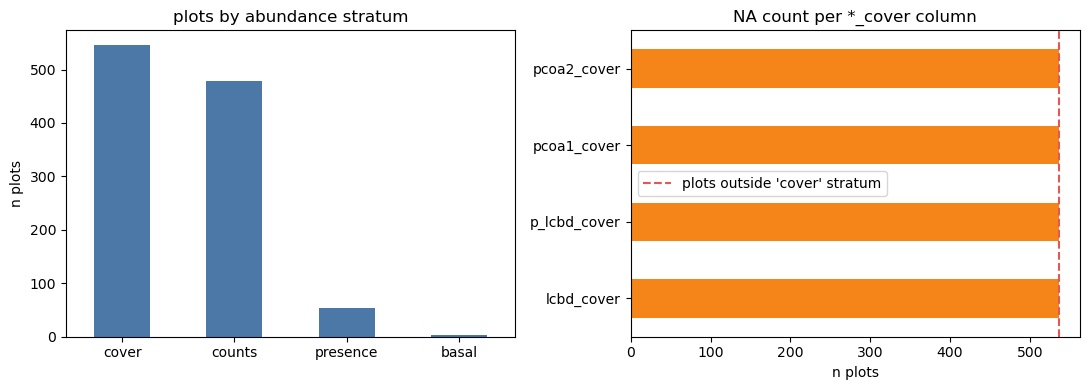

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
df['stratum'].value_counts().plot(kind='bar', ax=ax[0], color=BLUE)
ax[0].set(title='plots by abundance stratum', ylabel='n plots')
ax[0].tick_params(axis='x', rotation=0)

cover_cols = [c for c in df.columns if c.endswith('_cover')]
na_counts = df[cover_cols].isna().sum()
na_counts.plot(kind='barh', ax=ax[1], color=ORANGE)
ax[1].axvline((df['stratum'] != 'cover').sum(), color=RED, ls='--',
              label="plots outside 'cover' stratum")
ax[1].set(title='NA count per *_cover column', xlabel='n plots')
ax[1].legend()
fig.tight_layout()

## 5. Spatial pattern

Quick look at whether LCBD or richness cluster geographically before anyone treats
them as i.i.d. targets for cross-validation (they should not be — see
`src/biodiv/cv_groups.py` and the README's "Validacion" note on mandatory spatial
block CV).

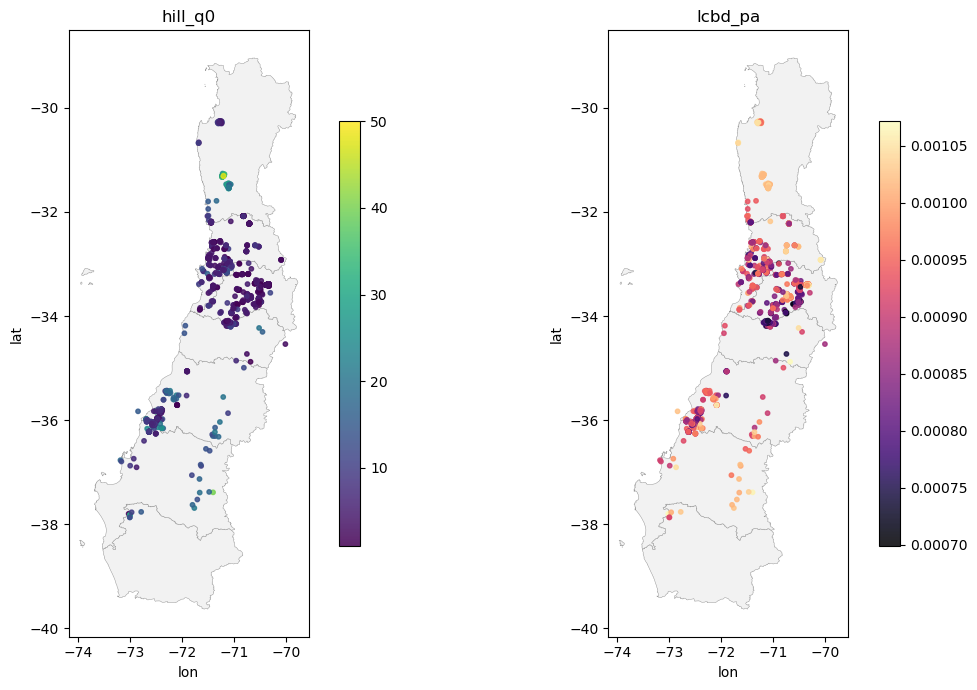

In [6]:
import geopandas as gpd

chile = gpd.read_file('../shapefiles/regiones_chile.shp')
chile = chile.to_crs('EPSG:4326')
chile = chile.cx[-73.5:-69.5, -38:-30]

fig, ax = plt.subplots(1, 2, figsize=(12, 7))
for a, col, cmap in zip(ax, ['hill_q0', 'lcbd_pa'], ['viridis', 'magma']):
    chile.plot(ax=a, facecolor='#F2F2F2', edgecolor='#9A9A9A', linewidth=0.35)
    sc = a.scatter(df['lon'], df['lat'], c=df[col], cmap=cmap, s=10, alpha=0.85)
    a.set(title=col, xlabel='lon', ylabel='lat', aspect='equal')
    fig.colorbar(sc, ax=a, shrink=0.7)
fig.tight_layout()

## 6. Any signal against predictors? (quick check before modeling)

Not a substitute for the actual model — just: is there *any* detectable relationship
between a response and an already-extracted predictor, before committing to training?
Same spirit as the topography-vs-phenology check in
`notebooks/01_explore_phenology_db.ipynb`, run the other direction (predictor vs
response). NDVI is used as the reference vegetation index for LSP metrics.

In [7]:
topo = pd.read_parquet(DERIVED / 'topography' / 'topography.parquet')
lsp_ndvi = (pd.read_parquet(DERIVED / 'lsp_all_auto.parquet')
              .query("index == 'ndvi'")
              .set_index('plot_id')[['los', 'ampl']])

pred = topo.set_index('plot_id')[['elevation', 'heat_load', 'northness']].join(lsp_ndvi)
d = df.set_index('PlotObservationID')[['hill_q0', 'hill_q1', 'lcbd_pa', 'lcbd_cover']].join(pred)

corr = d.corr(method='spearman', numeric_only=True).loc[
    ['hill_q0', 'hill_q1', 'lcbd_pa', 'lcbd_cover'],
    ['elevation', 'heat_load', 'northness', 'los', 'ampl'],
]
corr.style.background_gradient(cmap='coolwarm', vmin=-0.3, vmax=0.3).format('{:.2f}')

,elevation,heat_load,northness,los,ampl
hill_q0,-0.28,0.12,0.11,0.08,-0.17
hill_q1,-0.23,0.05,0.08,0.14,-0.14
lcbd_pa,0.27,-0.06,-0.15,0.04,-0.17
lcbd_cover,-0.18,0.03,0.01,0.04,0.05


## 7. Living Trees Chile — unified coverage

A second dataset, `data/Living_Trees_Chile.xlsx` (tree-level forest inventory, fixed
500 m² plots, 2011-2020), extends coverage south of Parcelas-CL's central-Chile band
(30-38°S) to the full length of the country. Built by `scripts/50_build_living_trees.py`
(plot table + occurrence table) and unified with Parcelas-CL's existing 1,082-plot
modelling subset by `scripts/51_build_unified_dataset.py` — Parcelas-CL's own filter
(lat 30-38°S, year ≥ 1999) is untouched, only Living Trees brings the wider footprint.

Two real data-quality catches, not silently absorbed:
- The genuine plot identity is the **coordinate**, not `um`/`region+um` — 2 coordinate
  pairs each carried two distinct `um` labels for the same physical site (a survey
  quirk, not a data-entry typo), merged into one plot.
- Reading the Excel without `keep_default_na=False` silently turns the species code
  `"NA"` (*Nothofagus alpina*) into a missing value — the same trap `io_parcelas.py`
  already avoids for the Parcelas-CL CSV. Fixed; only `SE` ("Sin especie") and 1
  unmatched code (`GD`) are genuinely unidentified (0.25% of records) — `ND`
  (*Nothofagus dombeyi*) and `NA` (*N. alpina*) are real, common species, kept.

Abundance currency: basal area per tree (`π/4 · (D/100)² · exp`, D in cm, `exp` the
expansion factor — trees/ha represented by the sampled tree), the standard forestry
dominance proxy — the same `"Basal_area"` stratum Parcelas-CL's own vocabulary already
has (`src/biodiv/io_parcelas.py:STRATUM`), just unused there until now.

Phylogenetic and dark-diversity facets are **not** computed for this unified set yet
(deferred, same phase-2 scope note as the intro above) — a quick check found the gap
is small: of 47 genera in Living Trees, 73 species resolve directly against the
V.PhyloMaker2 megatree's family table, 2 more (`Laureliopsis`, `Lithraea`) are already
in `scripts/lib/parcelas_comm.R`'s manual family list, and only 1 (`Tepualia`, family
Myrtaceae per GBIF/Kew POWO — not yet added, unverified against a taxonomic authority
per that list's own convention) would need a new manual entry.

In [8]:
lt_plots = pd.read_parquet(DERIVED / 'living_trees_plots.parquet')
unified_plots = pd.read_parquet(DERIVED / 'plots_unified.parquet')

print('Living Trees plots:', lt_plots.shape)
print('unified plots     :', unified_plots.shape)
print(unified_plots['source'].value_counts())

print('\nLiving Trees richness (basal-area species, per plot):')
print(lt_plots['richness'].describe())

print('\nLiving Trees plots by region:')
print(lt_plots['region'].value_counts())

Living Trees plots: (2020, 13)
unified plots     : (3102, 27)
living_trees    2020
parcelas_cl     1082
Name: source, dtype: int64

Living Trees richness (basal-area species, per plot):
count    2020.000000
mean        3.606931
std         2.302733
min         0.000000
25%         2.000000
50%         3.000000
75%         5.000000
max        12.000000
Name: richness, dtype: float64

Living Trees plots by region:
Aysén            425
Los Lagos        358
La Araucania     309
Los Rios         290
Bio-Bio          161
Maule            141
Magallanes       124
Ñuble             61
Valparaiso        50
O’Higgins         49
Metropolitana     38
Coquimbo          14
Name: region, dtype: int64


### 7a. Unified map — where does the new coverage sit?

Same basemap as §5, no longer clipped to the -38:-30 central-Chile box — Living Trees
reaches the full length of the country.

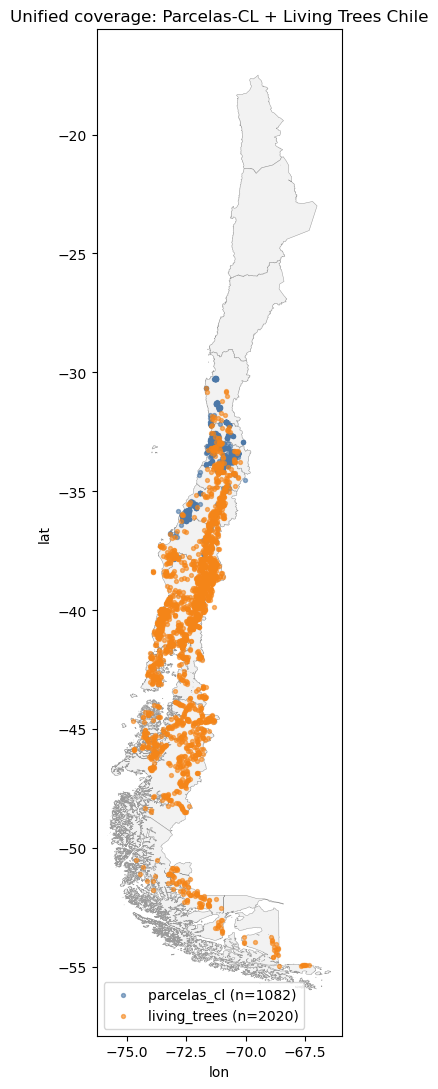

In [9]:
chile_full = gpd.read_file('../shapefiles/regiones_chile.shp').to_crs('EPSG:4326')

fig, ax = plt.subplots(figsize=(6, 11))
chile_full.plot(ax=ax, facecolor='#F2F2F2', edgecolor='#9A9A9A', linewidth=0.35)
for src, color in [('parcelas_cl', BLUE), ('living_trees', ORANGE)]:
    sub = unified_plots[unified_plots['source'] == src]
    ax.scatter(sub['lon'], sub['lat'], s=8, alpha=0.6, color=color,
               label=f'{src} (n={len(sub)})')
ax.set(title='Unified coverage: Parcelas-CL + Living Trees Chile',
      xlabel='lon', ylabel='lat', aspect='equal')
ax.legend(loc='lower left')
fig.tight_layout()

### 7b. `kfold5_block20_unified` — block balance over the bigger footprint

`scripts/53_unified_block20_folds.py` reuses `add_block_key`/`grouped_kfold` unchanged,
fed a Chile-centred Lambert Azimuthal Equal-Area projection (`X_m`/`Y_m`) instead of
Parcelas-CL's own UTM19S X/Y — raw UTM19S distorts badly far from its central
meridian, which matters now that the footprint reaches Magallanes (~55°S).

scheme: kfold5_block20_unified
plots with a fold assignment: 3102 of 3102


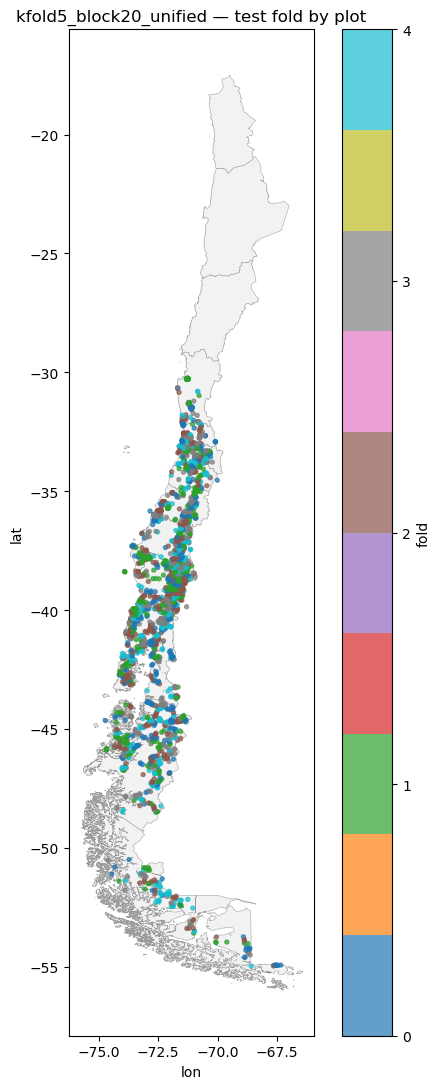

In [10]:
cv_block = pd.read_parquet(DERIVED / 'cv_folds_unified_block20.parquet')
block_test = cv_block[cv_block['split'] == 'test'][['PlotObservationID', 'fold']]
m = unified_plots.merge(block_test, on='PlotObservationID', how='left')
print('scheme:', cv_block['scheme'].iloc[0])
print('plots with a fold assignment:', m['fold'].notna().sum(), 'of', len(m))

fig, ax = plt.subplots(figsize=(6, 11))
chile_full.plot(ax=ax, facecolor='#F2F2F2', edgecolor='#9A9A9A', linewidth=0.35)
sc = ax.scatter(m['lon'], m['lat'], c=m['fold'], cmap='tab10', s=8, alpha=0.7)
ax.set(title='kfold5_block20_unified — test fold by plot',
      xlabel='lon', ylabel='lat', aspect='equal')
fig.colorbar(sc, ax=ax, label='fold', ticks=range(5))
fig.tight_layout()

### 7c. Unified diversity facets — `hill_q0`, `beta_pa`, `beta_freq`

`scripts/52_unified_diversity_facets.R`, same recipe as §1-§3 above
(`hillR`/`adespatial::beta.div`/`ape::pcoa` with Cailliez correction), run jointly over
Parcelas-CL + Living Trees:

- **`hill_q0_unified`** — richness, all 3,102 plots.
- **`pcoa*_pa_unified`/`lcbd_pa_unified`** — presence/absence (Jaccard), 3,094 plots (8
  Living Trees plots excluded: every tree missing `D`, zero basal area, an empty
  community row breaks the PCoA eigendecomposition — not a data-quality problem to
  paper over, a real gap in those 8 plots).
- **`pcoa*_freq_unified`/`lcbd_freq_unified`** — **new**, generalizes what `*_cover`
  above does only for the `cover` stratum: row-relativized abundance
  (`decostand(method="total")` + Hellinger/Bray), on every plot with *real* measured
  abundance (cover, individual counts, or basal area) — 3,040 plots. The `presence`
  stratum (`Abundance_parameter=="NA"`, `Value` fixed at 1 for every species in the
  plot) is excluded on purpose: relativizing a row of all-1s gives 1/richness per
  species, a flat-evenness artifact, not a measured frequency.

Sanity check already run in the R script: `cor(hill_q0_unified, richness) = 1.0000`.
PCoA axis **sign is arbitrary** per run (same caveat as `docs/17`/`docs/18` this
session) — a strong negative correlation between `pcoa1_pa_unified` and
`pcoa1_freq_unified` below is a sign flip, not disagreement. `beta_freq`'s 2 axes
explain only 7.0% of variance (below the 20% alert threshold `scripts/07` also uses) —
flagged, not hidden.

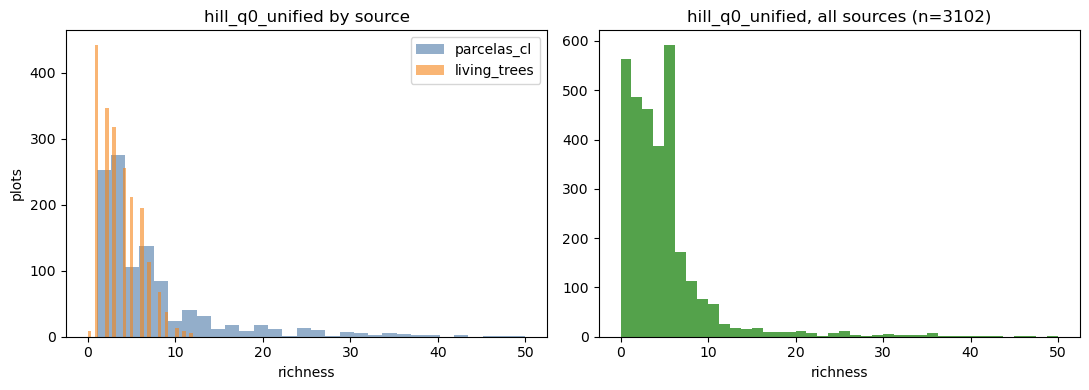

In [11]:
unified_resp = pd.read_parquet(DERIVED / 'unified_diversity_responses.parquet')
udf = unified_resp.merge(unified_plots, on='PlotObservationID', how='left')

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for src, color in [('parcelas_cl', BLUE), ('living_trees', ORANGE)]:
    sub = udf[udf['source'] == src]
    ax[0].hist(sub['hill_q0_unified'], bins=30, alpha=0.6, color=color, label=src)
ax[0].set(title='hill_q0_unified by source', xlabel='richness', ylabel='plots')
ax[0].legend()
ax[1].hist(udf['hill_q0_unified'], bins=40, color=GREEN)
ax[1].set(title='hill_q0_unified, all sources (n=%d)' % len(udf), xlabel='richness')
fig.tight_layout()

plots with both pcoa1_pa_unified and pcoa1_freq_unified: 3040
corr(pcoa1_pa_unified, pcoa1_freq_unified) = -0.906 (sign is arbitrary per PCoA run)


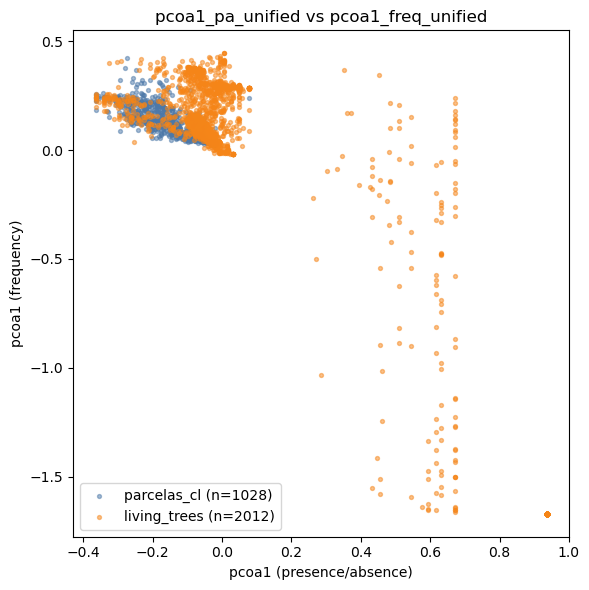

In [12]:
both = udf.dropna(subset=['pcoa1_pa_unified', 'pcoa1_freq_unified'])
print(f"plots with both pcoa1_pa_unified and pcoa1_freq_unified: {len(both)}")
print(f"corr(pcoa1_pa_unified, pcoa1_freq_unified) = "
      f"{both['pcoa1_pa_unified'].corr(both['pcoa1_freq_unified']):.3f} "
      "(sign is arbitrary per PCoA run)")

fig, ax = plt.subplots(figsize=(6, 6))
for src, color in [('parcelas_cl', BLUE), ('living_trees', ORANGE)]:
    sub = both[both['source'] == src]
    ax.scatter(sub['pcoa1_pa_unified'], sub['pcoa1_freq_unified'], s=8, alpha=0.5,
              color=color, label=f'{src} (n={len(sub)})')
ax.set(title='pcoa1_pa_unified vs pcoa1_freq_unified', xlabel='pcoa1 (presence/absence)',
      ylabel='pcoa1 (frequency)')
ax.legend()
fig.tight_layout()